Блок 1: Импорт данных

In [1]:
import os, glob
from itertools import combinations
from collections import defaultdict
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import hstack
from scipy.sparse.linalg import lsqr

import torch
import torch.nn as nn

# --- CONFIG ---
DATA_DIR = "data_nhl"
FILE_GLOB = "nhl_pbp*.csv"

KEEP_STRENGTH = "5x5"
MAX_EVENT_GAP_SEC = 60          # cap TOI per event gap
MIN_TOI_SEC = 5 * 60            # keep lineups with >= 5 minutes total TOI
MAX_PLAYERS = 800               # top players by TOI

# OLS greedy
OLS_START_CANDIDATES = 30
GREEDY_POOL = None              # None = all players; or e.g. 200

# HT
HT_RANK = 6
HT_EPOCHS = 30
HT_BATCH_SIZE = 1024
HT_LR = 2e-3
HT_WEIGHT_DECAY = 1e-4
HT_GRAD_CLIP = 1.0

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch device:", device)


Torch device: cuda


Блок 2: Проверка файлов

In [2]:
paths = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
assert len(paths) > 0, f"No files found in {DATA_DIR} matching {FILE_GLOB}"

print(f"Found {len(paths)} season files.")
print("First 5 files:")
for p in paths[:5]:
    print("  ", os.path.basename(p))



Found 16 season files.
First 5 files:
   nhl_pbp20072008.csv
   nhl_pbp20082009.csv
   nhl_pbp20092010.csv
   nhl_pbp20102011.csv
   nhl_pbp20112012.csv


Блок 3: Адаптация колонок

In [3]:
GAME_COL = "Game_Id"
PERIOD_COL = "Period"
SEC_COL = "Seconds_Elapsed"
STRENGTH_COL = "Strength"
EVENT_COL = "Event"
TEAMTYPE_COL = "Type"

home_cols = [f"homePlayer{i}_id" for i in range(1, 6)]
away_cols = [f"awayPlayer{i}_id" for i in range(1, 6)]

USE_COLS = [GAME_COL, PERIOD_COL, SEC_COL, STRENGTH_COL, EVENT_COL, TEAMTYPE_COL] + home_cols + away_cols


In [4]:
HOME_SCORE_COL = "Home_Score"
AWAY_SCORE_COL = "Away_Score"

# Добавляем счёт в список читаемых колонок
if HOME_SCORE_COL not in USE_COLS:
    USE_COLS = USE_COLS + [HOME_SCORE_COL, AWAY_SCORE_COL]

print("USE_COLS now contains score columns:", HOME_SCORE_COL in USE_COLS, AWAY_SCORE_COL in USE_COLS)

USE_COLS now contains score columns: True True


Блок 4: Статистика по пятеркам

In [5]:
from collections import defaultdict
import numpy as np
import pandas as pd

# ВАЖНО: убедись, что в USE_COLS добавлены колонки счёта
HOME_SCORE_COL = "Home_Score"
AWAY_SCORE_COL = "Away_Score"

if HOME_SCORE_COL not in USE_COLS:
    USE_COLS = USE_COLS + [HOME_SCORE_COL, AWAY_SCORE_COL]


# ---------- вспомогательные функции ----------

def to_int_player_id(v):
    """
    Универсальное приведение ID игрока к int.
    Работает для:
      8478439
      8478439.0
      "8478439"
      "8478439.0"
    """
    if pd.isna(v):
        return None
    try:
        return int(float(v))
    except Exception:
        return None


def sorted_tuple5(arr):
    ids = []
    for v in arr:
        pid = to_int_player_id(v)
        if pid is None:
            return None
        ids.append(pid)
    return tuple(sorted(ids))


# ---------- контейнеры статистик ----------

lineup_toi = defaultdict(float)
lineup_goals = defaultdict(float)
player_toi = defaultdict(float)


# ---------- основная функция обработки файла ----------

def process_one_file(path: str):

    df = pd.read_csv(path, usecols=USE_COLS)

    # фильтруем только 5x5
    if KEEP_STRENGTH is not None:
        df = df[df[STRENGTH_COL] == KEEP_STRENGTH].copy()

    # приводим время и счёт к числам
    df[PERIOD_COL] = pd.to_numeric(df[PERIOD_COL], errors="coerce")
    df[SEC_COL] = pd.to_numeric(df[SEC_COL], errors="coerce")
    df[HOME_SCORE_COL] = pd.to_numeric(df[HOME_SCORE_COL], errors="coerce")
    df[AWAY_SCORE_COL] = pd.to_numeric(df[AWAY_SCORE_COL], errors="coerce")

    # удаляем строки с пропусками
    df = df.dropna(
        subset=[GAME_COL, PERIOD_COL, SEC_COL,
                HOME_SCORE_COL, AWAY_SCORE_COL]
                + home_cols + away_cols
    ).copy()

    # финальные типы
    df[PERIOD_COL] = df[PERIOD_COL].astype(int)
    df[SEC_COL] = df[SEC_COL].astype(float)
    df[HOME_SCORE_COL] = df[HOME_SCORE_COL].astype(int)
    df[AWAY_SCORE_COL] = df[AWAY_SCORE_COL].astype(int)

    # сортировка
    df = df.sort_values([GAME_COL, PERIOD_COL, SEC_COL]).reset_index(drop=True)

    # ---------- цикл по матчам ----------
    for game_id, g in df.groupby(GAME_COL, sort=False):

        secs = g[SEC_COL].values
        periods = g[PERIOD_COL].values
        home_mat = g[home_cols].values
        away_mat = g[away_cols].values
        home_score = g[HOME_SCORE_COL].values
        away_score = g[AWAY_SCORE_COL].values

        n = len(g)
        if n < 2:
            continue

        for i in range(n - 1):

            # если новый период — секунды обнуляются
            if periods[i] != periods[i + 1]:
                continue

            dt = float(secs[i + 1] - secs[i])
            if dt <= 0:
                continue

            # ограничиваем dt
            dt = min(dt, float(MAX_EVENT_GAP_SEC))

            home5 = sorted_tuple5(home_mat[i])
            away5 = sorted_tuple5(away_mat[i])

            if home5 is None or away5 is None:
                continue

            # --- TOI ---
            lineup_toi[home5] += dt
            lineup_toi[away5] += dt

            for pid in home5:
                player_toi[pid] += dt
            for pid in away5:
                player_toi[pid] += dt

            # --- Goals через изменение счёта ---
            dh = home_score[i + 1] - home_score[i]
            da = away_score[i + 1] - away_score[i]

            if dh > 0:
                lineup_goals[home5] += float(dh)
            elif da > 0:
                lineup_goals[away5] += float(da)


# ---------- запуск по всем сезонам ----------

for k, path in enumerate(paths, 1):
    print(f"[{k}/{len(paths)}] {os.path.basename(path)}")
    process_one_file(path)

print("\n--- Block 4 results ---")
print("Unique lineups observed:", len(lineup_toi))
print("Lineups with >=1 goal:", len(lineup_goals))



[1/16] nhl_pbp20072008.csv
[2/16] nhl_pbp20082009.csv
[3/16] nhl_pbp20092010.csv
[4/16] nhl_pbp20102011.csv
[5/16] nhl_pbp20112012.csv
[6/16] nhl_pbp20122013.csv
[7/16] nhl_pbp20132014.csv
[8/16] nhl_pbp20142015.csv
[9/16] nhl_pbp20152016.csv
[10/16] nhl_pbp20162017.csv
[11/16] nhl_pbp20172018.csv
[12/16] nhl_pbp20182019.csv
[13/16] nhl_pbp20192020.csv
[14/16] nhl_pbp20202021.csv
[15/16] nhl_pbp20212022.csv
[16/16] nhl_pbp20222023.csv

--- Block 4 results ---
Unique lineups observed: 372875
Lineups with >=1 goal: 61879


In [6]:
print("Example TOI:", list(lineup_toi.items())[:1])
print("Example goals:", list(lineup_goals.items())[:5])


Example TOI: [((8445550, 8468598, 8469500, 8470606, 8471685), 2458.0)]
Example goals: [((8457403, 8459064, 8466260, 8468500, 8471677), 1.0), ((8457403, 8459064, 8470649, 8470744, 8471677), 1.0), ((8445550, 8462129, 8466304, 8468598, 8470113), 1.0), ((8458637, 8459424, 8459444, 8468434, 8470543), 1.0), ((8458637, 8459424, 8459427, 8459587, 8468635), 2.0)]


# Блок 5. Датасет v(S)=Goals per 60 + фильтр + сохранение

In [7]:
import os
import pandas as pd
import numpy as np

# 1) Собираем датасет по всем lineups из TOI
rows = []
for lineup, toi in lineup_toi.items():
    if toi <= 0:
        continue
    goals = float(lineup_goals.get(lineup, 0.0))
    goals_per60 = goals / toi * 3600.0
    rows.append((lineup, goals, toi, goals_per60))

lineups_df = pd.DataFrame(rows, columns=["lineup", "goals", "toi_sec", "goals_per60"])

print("--- Block 5: raw dataset ---")
print("Shape:", lineups_df.shape)
print(lineups_df[["goals", "toi_sec", "goals_per60"]].describe())

# 2) Фильтр по минимальному времени на льду (чтобы убрать “случайные” пятёрки)
before = len(lineups_df)
lineups_df = lineups_df[lineups_df["toi_sec"] >= MIN_TOI_SEC].reset_index(drop=True)
after = len(lineups_df)

print("\n--- Block 5: after MIN_TOI filter ---")
print(f"MIN_TOI_SEC = {MIN_TOI_SEC} sec ({MIN_TOI_SEC/60:.1f} min)")
print(f"Remaining: {after} / {before} ({after/before*100:.1f}%)")
print(lineups_df[["goals", "toi_sec", "goals_per60"]].describe())

# 3) Сохранение
os.makedirs("./artifacts", exist_ok=True)
dataset_path = "./artifacts/dataset_lineups_goals_per60.csv"
lineups_df.to_csv(dataset_path, index=False)
print("\nSaved:", dataset_path)

# 4) Быстрый просмотр
lineups_df.head(10)


--- Block 5: raw dataset ---
Shape: (372875, 4)
               goals        toi_sec    goals_per60
count  372875.000000  372875.000000  372875.000000
mean        0.264139     186.112912       5.993444
std         0.986890     545.660785      35.230232
min         0.000000       1.000000       0.000000
25%         0.000000      48.000000       0.000000
50%         0.000000      60.000000       0.000000
75%         0.000000     152.000000       0.000000
max        83.000000   50289.000000    3600.000000

--- Block 5: after MIN_TOI filter ---
MIN_TOI_SEC = 300 sec (5.0 min)
Remaining: 48225 / 372875 (12.9%)
              goals       toi_sec   goals_per60
count  48225.000000  48225.000000  48225.000000
mean       1.296133    891.844956      5.038227
std        2.354350   1305.106496      5.653634
min        0.000000    300.000000      0.000000
25%        0.000000    385.000000      0.000000
50%        1.000000    537.000000      4.215457
75%        2.000000    897.000000      8.463950
max 

,lineup,goals,toi_sec,goals_per60
0,"(8445550, 8468598, 8469500, 8470606, 8471685)",5.0,2458.0,7.323027
1,"(8457403, 8469120, 8470649, 8470744, 8471677)",0.0,304.0,0.000000
2,"(8467331, 8469500, 8470575, 8470606, 8471685)",6.0,2824.0,7.648725
3,"(8458637, 8459424, 8459427, 8459587, 8468635)",2.0,1866.0,3.858521
4,"(8457403, 8469500, 8470606, 8471677, 8471685)",2.0,2683.0,2.683563
5,"(8467387, 8467478, 8468434, 8470543, 8470621)",1.0,560.0,6.428571
6,"(8460661, 8467400, 8468434, 8470543, 8470621)",0.0,583.0,0.000000
7,"(8459064, 8466260, 8467331, 8468500, 8470575)",0.0,381.0,0.000000
8,"(8467331, 8469500, 8470606, 8471677, 8471685)",0.0,727.0,0.000000
9,"(8458637, 8459424, 8459444, 8468434, 8470543)",1.0,365.0,9.863014


# Блок 6. Ограничение на топ игроков по TOI + фильтр пятёрок

In [9]:
import numpy as np

# 1) Берём игроков с максимальным суммарным TOI (во всех событиях 5x5)
player_toi_items = sorted(player_toi.items(), key=lambda x: x[1], reverse=True)

top_players = [pid for pid, _ in player_toi_items[:MAX_PLAYERS]]
player_to_idx = {pid: i for i, pid in enumerate(top_players)}
idx_to_player = {i: pid for pid, i in player_to_idx.items()}

print("--- Block 6: top players by TOI ---")
print("Requested MAX_PLAYERS:", MAX_PLAYERS)
print("Selected players:", len(top_players))
print("Top-5 players by TOI (player_id, toi_sec):", player_toi_items[:5])

# 2) Оставляем только те lineups, где все 5 игроков входят в top_players
def lineup_in_top(lineup):
    return all(pid in player_to_idx for pid in lineup)

before = len(lineups_df)
mask = lineups_df["lineup"].map(lineup_in_top)
lineups_df = lineups_df[mask].reset_index(drop=True)
after = len(lineups_df)

print("\n--- Block 6: lineup filtering ---")
print(f"Lineups kept: {after} / {before} ({after/before*100:.1f}%)")

# 3) Итоговые размеры
n_samples = len(lineups_df)
n_players = len(top_players)

print("\n--- Block 6: results ---")
print("n_lineups (samples):", n_samples)
print("n_players:", n_players)

lineups_df.head(10)


--- Block 6: top players by TOI ---
Requested MAX_PLAYERS: 800
Selected players: 800
Top-5 players by TOI (player_id, toi_sec): [(8470600, 964346.0), (8474563, 884222.0), (8470281, 881055.0), (8465009, 844708.0), (8470642, 804351.0)]

--- Block 6: lineup filtering ---
Lineups kept: 17957 / 48225 (37.2%)

--- Block 6: results ---
n_lineups (samples): 17957
n_players: 800


,lineup,goals,toi_sec,goals_per60
0,"(8467331, 8469500, 8470606, 8471677, 8471685)",0.0,727.0,0.000000
1,"(8458637, 8459424, 8459444, 8468434, 8470543)",1.0,365.0,9.863014
2,"(8459424, 8467400, 8470543, 8470612, 8470621)",1.0,791.0,4.551201
3,"(8459442, 8467496, 8467545, 8469460, 8470274)",13.0,5755.0,8.132059
4,"(8458529, 8465914, 8468309, 8470603, 8471362)",1.0,428.0,8.411215
5,"(8458529, 8467496, 8469460, 8469521, 8470603)",25.0,14262.0,6.310475
6,"(8458938, 8459442, 8467545, 8468309, 8470274)",1.0,953.0,3.777545
7,"(8457063, 8467463, 8467856, 8468083, 8470201)",1.0,739.0,4.871448
8,"(8458637, 8459424, 8470543, 8470612, 8470621)",9.0,3165.0,10.236967
9,"(8457063, 8466149, 8467463, 8467856, 8468083)",2.0,1674.0,4.301075


# Блок 7. Подготовка X_idx, y, w

In [10]:
import numpy as np
import pandas as pd

# 1) X_idx: (n_samples, 5) — индексы игроков (0..n_players-1)
n_samples = len(lineups_df)

X_idx = np.zeros((n_samples, 5), dtype=np.int64)

for i, lineup in enumerate(lineups_df["lineup"].values):
    # lineup хранится как tuple из player_id
    X_idx[i] = np.array([player_to_idx[int(pid)] for pid in lineup], dtype=np.int64)

# 2) y: Goals per 60
y = lineups_df["goals_per60"].values.astype(np.float32)

# 3) w: веса по TOI (чем больше TOI, тем надёжнее оценка Goals/60)
w = lineups_df["toi_sec"].values.astype(np.float32)
w = w / (float(w.mean()) + 1e-9)

print("--- Block 7 results ---")
print("X_idx shape:", X_idx.shape)
print("y shape:", y.shape, "| y mean/std:", float(y.mean()), float(y.std()))
print("w shape:", w.shape, "| w mean/min/max:", float(w.mean()), float(w.min()), float(w.max()))

# sanity: первые 3 строки
print("\nFirst 3 samples:")
for i in range(3):
    print("lineup_ids:", lineups_df.loc[i, "lineup"])
    print("lineup_idx:", X_idx[i].tolist(), "y:", float(y[i]), "w:", float(w[i]))
    print("---")


--- Block 7 results ---
X_idx shape: (17957, 5)
y shape: (17957,) | y mean/std: 5.137527942657471 5.422685623168945
w shape: (17957,) | w mean/min/max: 1.0 0.25574567914009094 42.87064743041992

First 3 samples:
lineup_ids: (8467331, 8469500, 8470606, 8471677, 8471685)
lineup_idx: [203, 235, 39, 33, 12] y: 0.0 w: 0.6197569966316223
---
lineup_ids: (8458637, 8459424, 8459444, 8468434, 8470543)
lineup_idx: [642, 569, 555, 726, 108] y: 9.86301326751709 w: 0.3111572265625
---
lineup_ids: (8459424, 8467400, 8470543, 8470612, 8470621)
lineup_idx: [569, 88, 108, 43, 55] y: 4.551200866699219 w: 0.6743160486221313
---


# Блок 8. WLS OLS + остатки + гистограмма

In [11]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse import hstack
from scipy.sparse.linalg import lsqr
from itertools import combinations
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Model: y = sum_i a_i * 1{i in lineup} + sum_{i<j} b_ij * 1{i,j in lineup} + eps
# eps = "общая ошибка наблюдения" (не индивидуальная по игроку)
# We fit it by Weighted Least Squares with weights w ~ TOI.
# ---------------------------------------------------------

# ---------- 1) Build sparse design matrix X = [X_ind | X_pair] ----------

# Individual features
rows_i, cols_i, data_i = [], [], []
for r in range(n_samples):
    for p in X_idx[r]:
        rows_i.append(r)
        cols_i.append(int(p))
        data_i.append(1.0)

X_ind = sp.csr_matrix((data_i, (rows_i, cols_i)), shape=(n_samples, n_players))
print("X_ind:", X_ind.shape)

# Pair features (only pairs observed in the dataset)
pair_to_idx = {}
rows_p, cols_p, data_p = [], [], []
for r in range(n_samples):
    ps = X_idx[r]
    for u, v in combinations(ps, 2):
        u = int(u); v = int(v)
        key = (u, v) if u < v else (v, u)
        if key not in pair_to_idx:
            pair_to_idx[key] = len(pair_to_idx)
        j = pair_to_idx[key]
        rows_p.append(r)
        cols_p.append(j)
        data_p.append(1.0)

n_pairs = len(pair_to_idx)
X_pair = sp.csr_matrix((data_p, (rows_p, cols_p)), shape=(n_samples, n_pairs))
print("X_pair:", X_pair.shape)

# Full design matrix
X = hstack([X_ind, X_pair], format="csr")
print("X:", X.shape, "| total params:", X.shape[1])

# ---------- 2) Weighted Least Squares via lsqr ----------

sqrtw = np.sqrt(w).astype(np.float64)
W = sp.diags(sqrtw, offsets=0, format="csr")

Xw = W @ X
yw = sqrtw * y.astype(np.float64)

print("Solving WLS (lsqr)...")
res = lsqr(Xw, yw)
coef = res[0].astype(np.float64)

a = coef[:n_players]
b = coef[n_players:]

print("\n--- Block 8: fitted coefficients ---")
print("a range:", float(a.min()), "to", float(a.max()))
print("b range:", float(b.min()), "to", float(b.max()))
print("n_pairs:", n_pairs)

# ---------- 3) Predictions & residuals (for histogram) ----------
# We compute y_hat without multiplying full X again (faster & clear)

y_hat = np.zeros(n_samples, dtype=np.float64)

# individual part
for r in range(n_samples):
    y_hat[r] += float(a[X_idx[r]].sum())

# pair part
for r in range(n_samples):
    ps = X_idx[r]
    s = 0.0
    for i in range(5):
        for j in range(i + 1, 5):
            u, v = int(ps[i]), int(ps[j])
            key = (u, v) if u < v else (v, u)
            pj = pair_to_idx.get(key, None)
            if pj is not None:
                s += float(b[pj])
    y_hat[r] += s

resid = y.astype(np.float64) - y_hat

print("\n--- Block 8: residuals ---")
print("resid mean:", float(resid.mean()))
print("resid std :", float(resid.std()))
print("resid min/max:", float(resid.min()), float(resid.max()))

# Weighted RMSE (since we fit WLS)
wrmse = np.sqrt(np.average(resid**2, weights=w))
print("Weighted RMSE:", float(wrmse))


X_ind: (17957, 800)
X_pair: (17957, 21523)
X: (17957, 22323) | total params: 22323
Solving WLS (lsqr)...

--- Block 8: fitted coefficients ---
a range: -14.736203469199232 to 10.962763076735348
b range: -92.79015159827489 to 81.6209241140761
n_pairs: 21523

--- Block 8: residuals ---
resid mean: -0.008702523233654166
resid std : 2.2400217676361796
resid min/max: -14.096043912844904 19.250361726040186
Weighted RMSE: 1.6202421069406427


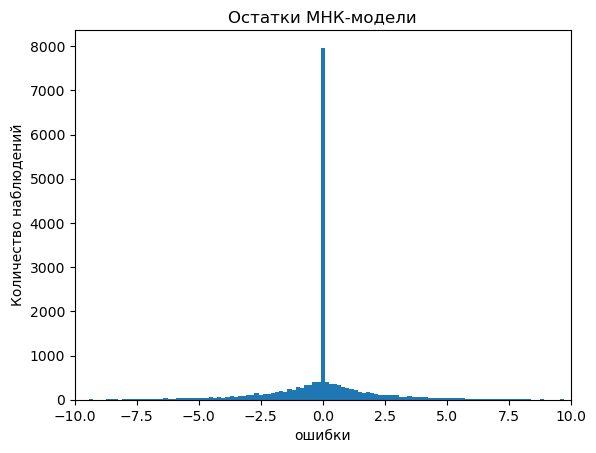

In [12]:
# ---------- 4) Histogram of residuals ----------
plt.figure()
plt.hist(resid, bins=200)
plt.title("Остатки МНК-модели")
plt.xlabel("ошибки")
plt.ylabel("Количество наблюдений")
plt.xlim(-10, 10)
plt.show()


In [13]:
import numpy as np
from itertools import combinations

# 1) Универсальный предиктор для коалиции любого размера (k=1..5)
def ols_predict(players_idx):
    players_idx = list(map(int, players_idx))
    s = float(a[players_idx].sum())

    # добавляем парные эффекты только для имеющихся пар
    for u, v in combinations(players_idx, 2):
        key = (u, v) if u < v else (v, u)
        pj = pair_to_idx.get(key, None)
        if pj is not None:
            s += float(b[pj])
    return s

# 2) Кандидаты: стартуем с топа по a_i
players_ranked = sorted(range(n_players), key=lambda i: a[i], reverse=True)
start_candidates = players_ranked[:min(OLS_START_CANDIDATES, n_players)]

# Пул перебора на каждом шаге greedy
if GREEDY_POOL is None:
    candidate_players = list(range(n_players))
else:
    candidate_players = players_ranked[:min(GREEDY_POOL, n_players)]

print("--- Block 9 setup ---")
print("start_candidates:", len(start_candidates))
print("candidate_players pool:", len(candidate_players))

# 3) Greedy-поиск лучшей пятёрки
best_score_ols, best_five_ols = -1e18, None

for st in start_candidates:
    S = [st]
    while len(S) < 5:
        best_j, best_val = None, -1e18

        for j in candidate_players:
            if j in S:
                continue
            val = ols_predict(S + [j])   # теперь безопасно для размера 2..5
            if val > best_val:
                best_val = val
                best_j = j

        S.append(best_j)

    sc = ols_predict(S)
    if sc > best_score_ols:
        best_score_ols, best_five_ols = sc, S

# 4) Вывод результата
best_player_ids = [int(idx_to_player[i]) for i in best_five_ols]

print("\n--- Block 9 results ---")
print("OLS best predicted Goals/60:", float(best_score_ols))
print("Best five (idx):", best_five_ols)
print("Best five (player_id):", best_player_ids)

# 5) Разложение на индивидуальную и парную часть + топ пар
sum_a = float(a[best_five_ols].sum())
sum_b = 0.0
pairs = []

for u, v in combinations(best_five_ols, 2):
    key = (u, v) if u < v else (v, u)
    pj = pair_to_idx.get(key, None)
    if pj is not None:
        val = float(b[pj])
        sum_b += val
        pairs.append((int(idx_to_player[u]), int(idx_to_player[v]), val))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\nDecomposition:")
print("sum a_i:", sum_a)
print("sum b_ij:", sum_b)
print("sum total:", sum_a + sum_b)

print("\nTop pair synergies inside best five:")
for (p1, p2, val) in pairs_sorted[:10]:
    print(p1, p2, val)


--- Block 9 setup ---
start_candidates: 30
candidate_players pool: 800

--- Block 9 results ---
OLS best predicted Goals/60: 263.0424302552664
Best five (idx): [583, 558, 103, 46, 434]
Best five (player_id): [8476925, 8475625, 8471707, 8473533, 8465951]

Decomposition:
sum a_i: 22.470459465820507
sum b_ij: 240.57197078944588
sum total: 263.04243025526637

Top pair synergies inside best five:
8471707 8473533 81.6209241140761
8476925 8475625 62.97996319225792
8475625 8471707 43.18695522402958
8471707 8465951 37.89804093864688
8473533 8465951 8.489182293923998
8476925 8471707 6.396905026511401


In [14]:
import pandas as pd

player_id_to_name = {}

name_cols = ["p1_name", "p2_name", "p3_name"]
id_cols   = ["p1_ID",   "p2_ID",   "p3_ID"]

for path in paths:
    df = pd.read_csv(path, usecols=name_cols + id_cols)

    for name_col, id_col in zip(name_cols, id_cols):
        ids = df[id_col].values
        names = df[name_col].values

        for pid, name in zip(ids, names):
            if pd.isna(pid) or pd.isna(name):
                continue
            try:
                pid_int = int(float(pid))
                if pid_int not in player_id_to_name:
                    player_id_to_name[pid_int] = name
            except:
                continue

print("Total unique players with names:", len(player_id_to_name))


Total unique players with names: 2595


# Блок 9: Лучшие составы МНК

In [15]:
print("Best five (with names):")

for pid in best_player_ids:
    name = player_id_to_name.get(pid, "Unknown")
    print(pid, "->", name)


Best five (with names):
8476925 -> COLTON SISSONS
8475625 -> MATT IRWIN
8471707 -> JAMES NEAL
8473533 -> JORDAN STAAL
8465951 -> MATT COOKE


In [16]:
import pandas as pd

player_id_to_name = {}

name_cols = ["p1_name", "p2_name", "p3_name"]
id_cols   = ["p1_ID",   "p2_ID",   "p3_ID"]

for path in paths:
    df = pd.read_csv(path, usecols=name_cols + id_cols)

    for name_col, id_col in zip(name_cols, id_cols):
        ids = df[id_col].values
        names = df[name_col].values

        for pid, name in zip(ids, names):
            if pd.isna(pid) or pd.isna(name):
                continue
            try:
                pid_int = int(float(pid))
                if pid_int not in player_id_to_name:
                    player_id_to_name[pid_int] = str(name).strip()
            except:
                continue

print("Total players with names:", len(player_id_to_name))

def pid_name(pid: int) -> str:
    return player_id_to_name.get(int(pid), "Unknown")


Total players with names: 2595


In [17]:
import pandas as pd
import numpy as np

# индекс 0..n_players-1 -> player_id
player_ids = np.array([int(idx_to_player[i]) for i in range(n_players)], dtype=int)

top15_idx = np.argsort(a)[::-1][:15]

rows = []
for i in top15_idx:
    pid = int(player_ids[i])
    rows.append({
        "rank": len(rows)+1,
        "player_id": pid,
        "name": pid_name(pid),
        "a_i": float(a[i])
    })

top15_players_df = pd.DataFrame(rows)
top15_players_df


,rank,player_id,name,a_i
0,1,8470162,MATT STAJAN,10.962763
1,2,8474091,BRANDON SUTTER,10.383842
2,3,8471228,ALEXANDER RADULOV,10.207343
3,4,8471675,SIDNEY CROSBY,10.024860
4,5,8470610,ZACH PARISE,9.735935
5,6,8476468,JT MILLER,9.008914
6,7,8470611,ERIC FEHR,8.829863
7,8,8470630,KEVIN KLEIN,8.731536
8,9,8477940,NIKOLAJ EHLERS,8.685135
9,10,8475728,JOHAN LARSSON,8.562682


In [18]:
import pandas as pd
import numpy as np
from itertools import combinations

# -------- 1) TOP-15 pairs by b_ij --------

# сделаем обратное отображение idx пары -> (u_idx, v_idx)
idx_to_pair = [None] * len(pair_to_idx)
for (u, v), j in pair_to_idx.items():
    idx_to_pair[j] = (u, v)

top15_pair_idx = np.argsort(b)[::-1][:15]

rows = []
for rank, j in enumerate(top15_pair_idx, start=1):
    u_idx, v_idx = idx_to_pair[j]
    pid_u = int(idx_to_player[u_idx])
    pid_v = int(idx_to_player[v_idx])

    rows.append({
        "rank": rank,
        "player1_id": pid_u,
        "player1_name": pid_name(pid_u),
        "player2_id": pid_v,
        "player2_name": pid_name(pid_v),
        "b_ij": float(b[j])
    })

top15_pairs_df = pd.DataFrame(rows)

print("TOP-15 pairs by b_ij:")
top15_pairs_df


# -------- 2) Best five (OLS) with decomposition --------

best_ids = [int(idx_to_player[i]) for i in best_five_ols]
best_names = [pid_name(pid) for pid in best_ids]

# индивидуальные вклады
ind_rows = []
for u_idx in best_five_ols:
    pid = int(idx_to_player[u_idx])
    ind_rows.append({
        "player_id": pid,
        "name": pid_name(pid),
        "a_i": float(a[u_idx])
    })
best_individual_df = pd.DataFrame(ind_rows).sort_values("a_i", ascending=False)

# парные вклады
pair_rows = []
sum_b = 0.0
for u_idx, v_idx in combinations(best_five_ols, 2):
    key = (u_idx, v_idx) if u_idx < v_idx else (v_idx, u_idx)
    j = pair_to_idx.get(key, None)
    if j is None:
        continue
    val = float(b[j])
    sum_b += val

    pid_u = int(idx_to_player[u_idx])
    pid_v = int(idx_to_player[v_idx])
    pair_rows.append({
        "player1_id": pid_u,
        "player1_name": pid_name(pid_u),
        "player2_id": pid_v,
        "player2_name": pid_name(pid_v),
        "b_ij": val
    })

best_pairs_df = pd.DataFrame(pair_rows).sort_values("b_ij", ascending=False)

sum_a = float(best_individual_df["a_i"].sum())
total = sum_a + float(best_pairs_df["b_ij"].sum())

print("\n=== Best five (OLS) ===")
print("Predicted Goals/60:", float(best_score_ols))
print("Player IDs:", best_ids)
print("Names:", best_names)

print("\nIndividual contributions (a_i):")
best_individual_df

print("\nPair contributions (b_ij) inside best five:")
best_pairs_df

print("\nDecomposition sums:")
print("sum a_i =", sum_a)
print("sum b_ij =", float(best_pairs_df['b_ij'].sum()))
print("total   =", total)


TOP-15 pairs by b_ij:

=== Best five (OLS) ===
Predicted Goals/60: 263.0424302552664
Player IDs: [8476925, 8475625, 8471707, 8473533, 8465951]
Names: ['COLTON SISSONS', 'MATT IRWIN', 'JAMES NEAL', 'JORDAN STAAL', 'MATT COOKE']

Individual contributions (a_i):

Pair contributions (b_ij) inside best five:

Decomposition sums:
sum a_i = 22.470459465820507
sum b_ij = 240.57197078944588
total   = 263.04243025526637


In [19]:
top15_pairs_df


,rank,player1_id,player1_name,player2_id,player2_name,b_ij
0,1,8473533,JORDAN STAAL,8471707,JAMES NEAL,81.620924
1,2,8471426,TROY BROUWER,8474519,JACK HILLEN,80.883007
2,3,8467371,MIKE RIBEIRO,8468501,ANTON VOLCHENKOV,67.275018
3,4,8475763,KEVIN HAYES,8470854,TANNER GLASS,64.308281
4,5,8467389,BRAD RICHARDS,8475855,JESPER FAST,63.009754
5,6,8475625,MATT IRWIN,8476925,COLTON SISSONS,62.979963
6,7,8475158,RYAN O'REILLY,8475728,JOHAN LARSSON,61.204789
7,8,8474176,CARL HAGELIN,8468575,DOMINIC MOORE,58.692200
8,9,8470630,KEVIN KLEIN,8476887,FILIP FORSBERG,56.932489
9,10,8466140,OLLI JOKINEN,8474569,COLIN WILSON,54.605463


In [20]:
import pandas as pd
from itertools import combinations
from IPython.display import display

# --- 1) Таблица по игрокам (индивидуальные вклады a_i) ---
players_rows = []
for u_idx in best_five_ols:
    pid = int(idx_to_player[u_idx])
    players_rows.append({
        "player_id": pid,
        "name": pid_name(pid),
        "a_i (individual)": float(a[u_idx])
    })

players_df = pd.DataFrame(players_rows).sort_values("a_i (individual)", ascending=False).reset_index(drop=True)

# --- 2) Таблица по парам (парные вклады b_ij внутри этой пятёрки) ---
pairs_rows = []
for u_idx, v_idx in combinations(best_five_ols, 2):
    key = (u_idx, v_idx) if u_idx < v_idx else (v_idx, u_idx)
    j = pair_to_idx.get(key, None)

    pid_u = int(idx_to_player[u_idx])
    pid_v = int(idx_to_player[v_idx])

    # если пары нет в словаре (не встречалась в данных), считаем вклад 0
    bij = float(b[j]) if j is not None else 0.0

    pairs_rows.append({
        "player1": f"{pid_name(pid_u)} ({pid_u})",
        "player2": f"{pid_name(pid_v)} ({pid_v})",
        "b_ij (pair)": bij
    })

pairs_df = pd.DataFrame(pairs_rows).sort_values("b_ij (pair)", ascending=False).reset_index(drop=True)

# --- 3) Суммы ---
sum_a = float(players_df["a_i (individual)"].sum())
sum_b = float(pairs_df["b_ij (pair)"].sum())
total = sum_a + sum_b

summary_df = pd.DataFrame([{
    "sum a_i": sum_a,
    "sum b_ij": sum_b,
    "total predicted (a+b)": total,
    "best_score_ols (from greedy)": float(best_score_ols)
}])

print("=== Best five (OLS) — individual contributions ===")
display(players_df)

print("\n=== Best five (OLS) — pair contributions ===")
display(pairs_df)

print("\n=== Decomposition summary ===")
display(summary_df)


=== Best five (OLS) — individual contributions ===


,player_id,name,a_i (individual)
0,8476925,COLTON SISSONS,8.192567
1,8473533,JORDAN STAAL,6.535347
2,8471707,JAMES NEAL,4.663470
3,8465951,MATT COOKE,4.300601
4,8475625,MATT IRWIN,-1.221526



=== Best five (OLS) — pair contributions ===


,player1,player2,b_ij (pair)
0,JAMES NEAL (8471707),JORDAN STAAL (8473533),81.620924
1,COLTON SISSONS (8476925),MATT IRWIN (8475625),62.979963
2,MATT IRWIN (8475625),JAMES NEAL (8471707),43.186955
3,JAMES NEAL (8471707),MATT COOKE (8465951),37.898041
4,JORDAN STAAL (8473533),MATT COOKE (8465951),8.489182
5,COLTON SISSONS (8476925),JAMES NEAL (8471707),6.396905
6,COLTON SISSONS (8476925),JORDAN STAAL (8473533),0.000000
7,COLTON SISSONS (8476925),MATT COOKE (8465951),0.000000
8,MATT IRWIN (8475625),JORDAN STAAL (8473533),0.000000
9,MATT IRWIN (8475625),MATT COOKE (8465951),0.000000



=== Decomposition summary ===


,sum a_i,sum b_ij,total predicted (a+b),best_score_ols (from greedy)
0,22.470459,240.571971,263.04243,263.04243


# Блок 10 HT

In [25]:
HT_RANK = 3
HT_EPOCHS = 30
HT_BATCH_SIZE = 1024
HT_LR = 5e-4
HT_WEIGHT_DECAY = 5e-3
HT_GRAD_CLIP = 1.0


In [26]:
import torch
import torch.nn as nn

# ===== device / dtype =====
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print("Using device:", device)

# ===== SimpleHT classes (как в скрипте научрука) =====
class HTNode:
    """Узел HT дерева"""
    def __init__(self, rank, shapes, tensor_index, parent=None, node_type=None):
        self.type = node_type
        self.tensor_index = tensor_index
        self.rank = rank
        self.parent = parent
        self.shapes = shapes

    def init_core(self, rand_func="randn", dtype=torch.float32, device="cpu"):
        if rand_func == "randn":
            def rand_func(*sh):
                return torch.randn(*sh, dtype=dtype, device=device)

        if self.type == "leaf":
            core = rand_func(self.shapes, self.rank)              # (n, r)
        elif self.type == "node":
            core = rand_func(self.rank, self.rank, self.rank)     # (r, r, r)
        else:  # root
            core = rand_func(self.rank, self.rank, 1)             # (r, r, 1)

        self.core = nn.Parameter(core)
        return self.core

    def init_core_all(self, cores, rand_func="randn", dtype=torch.float32, device="cpu"):
        cores.append(self.init_core(rand_func=rand_func, dtype=dtype, device=device))
        for node in self.childrens:
            node.init_core_all(cores, rand_func=rand_func, dtype=dtype, device=device)

    def evaluate(self, indices):
        """Рекурсивное вычисление значения узла"""
        if self.type == "leaf":
            idx = indices[:, self.tensor_index]                   # (bs,)
            return self.core[idx, ...]                            # (bs, r)
        else:
            # left: (bs,r), right:(bs,r), core:(r,r,r/root)
            result = torch.einsum("ka,kb,abc->kc",
                                  *[node.evaluate(indices) for node in self.childrens],
                                  self.core)
            return result

    def build_childrens(self):
        n = len(self.shapes)

        # лист
        if n == 1:
            self.type = "leaf"
            self.shapes = int(self.shapes[0])
            self.tensor_index = int(self.tensor_index[0])
            self.childrens = []
            return self

        # внутренний узел
        if self.type is None:
            self.type = "node"

        left_n = (n + 1) // 2
        self.childrens = [
            HTNode(rank=self.rank, shapes=self.shapes[:left_n], tensor_index=self.tensor_index[:left_n], parent=self),
            HTNode(rank=self.rank, shapes=self.shapes[left_n:], tensor_index=self.tensor_index[left_n:], parent=self),
        ]
        for node in self.childrens:
            node.build_childrens()


class HTDecomposition(nn.Module):
    def __init__(self, shapes, rank=2, dtype=torch.float32, device="cpu"):
        super().__init__()
        self.shapes = shapes
        self.dim = len(shapes)
        self.rank = rank
        self.dtype = dtype
        self.device = device

        self.root, cores = self._build_tree()
        self.cores = nn.ParameterList(cores)

    def _build_tree(self, rand_func="randn"):
        root = HTNode(node_type="root", rank=self.rank, shapes=self.shapes, tensor_index=list(range(self.dim)))
        root.build_childrens()

        cores = []
        root.init_core_all(cores, rand_func=rand_func, dtype=self.dtype, device=self.device)
        return root, cores

    def forward(self, idx):
        # idx: (bs, 5) индексы игроков
        return self.root.evaluate(idx).squeeze(dim=-1)  # (bs,)


# ===== init model =====
# IMPORTANT: shapes = (n_players,)*5
model = HTDecomposition(shapes=(n_players,) * 5, rank=HT_RANK, dtype=dtype, device=device).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("\n--- Block 10 results ---")
print("HT_RANK:", HT_RANK)
print("n_players:", n_players)
print("n_params:", n_params)

# ===== quick forward sanity-check =====
idx_test = torch.tensor(X_idx[:4], dtype=torch.long, device=device)  # (4,5)
with torch.no_grad():
    out = model(idx_test)
print("Sanity forward output shape:", tuple(out.shape))
print("Sanity forward output:", out.detach().cpu().numpy())


Using device: cuda

--- Block 10 results ---
HT_RANK: 3
n_players: 800
n_params: 12090
Sanity forward output shape: (4,)
Sanity forward output: [ 16.714108 -65.19976   14.396281 -74.54413 ]


In [27]:
import torch
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


cuda available: True
gpu: NVIDIA A100-SXM4-80GB MIG 2g.20gb


In [28]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------- defaults / config ----------
HT_EPOCHS = globals().get("HT_EPOCHS", 80)              # сделаем больше
HT_BATCH_SIZE = globals().get("HT_BATCH_SIZE", 2048)    # на GPU можно 2048-8192
HT_LR = globals().get("HT_LR", 2e-3)                    # обычно чуть выше ок
HT_WEIGHT_DECAY = globals().get("HT_WEIGHT_DECAY", 1e-4)
HT_GRAD_CLIP = globals().get("HT_GRAD_CLIP", 1.0)
VAL_FRAC = globals().get("VAL_FRAC", 0.2)
SEED = globals().get("SEED", 42)

EARLY_STOP_PATIENCE = globals().get("EARLY_STOP_PATIENCE", 10)
MIN_DELTA = globals().get("MIN_DELTA", 1e-4)

NUM_WORKERS = globals().get("NUM_WORKERS", 2)
PIN_MEMORY = globals().get("PIN_MEMORY", True)

device = next(model.parameters()).device
use_amp = (device.type == "cuda")
print("Device:", device, "| AMP:", use_amp)

# ---------- split ----------
rng = np.random.default_rng(SEED)
n = len(y)
perm = rng.permutation(n)
n_val = int(n * VAL_FRAC)
val_idx = perm[:n_val]
train_idx = perm[n_val:]

X_train, y_train, w_train = X_idx[train_idx], y[train_idx], w[train_idx]
X_val, y_val, w_val = X_idx[val_idx], y[val_idx], w[val_idx]

# ---------- normalize target (fit on train only) ----------
y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train) + 1e-8)

y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std

print("--- Target normalization ---")
print("y_mean:", y_mean, "y_std:", y_std)

# ---------- Dataset ----------
class LineupDataset(Dataset):
    def __init__(self, X, y, w):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.w = torch.tensor(w, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.w[i]

train_ds = LineupDataset(X_train, y_train_n, w_train)
val_ds = LineupDataset(X_val, y_val_n, w_val)

train_loader = DataLoader(
    train_ds, batch_size=HT_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=HT_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

print("--- Block 11 setup ---")
print("n_train:", len(train_ds), "| n_val:", len(val_ds))
print("batch_size:", HT_BATCH_SIZE, "| epochs:", HT_EPOCHS)
print("lr:", HT_LR, "| wd:", HT_WEIGHT_DECAY, "| clip:", HT_GRAD_CLIP)

# ---------- optimizer / scheduler ----------
optimizer = torch.optim.AdamW(model.parameters(), lr=HT_LR, weight_decay=HT_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HT_EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def weighted_mse(pred, target, weight):
    return torch.mean(weight * (pred - target) ** 2)

@torch.no_grad()
def eval_loader(loader):
    model.eval()
    total_w = 0.0
    total_wse = 0.0
    for xb, yb, wb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        wb = wb.to(device, non_blocking=True)

        pred = model(xb)
        total_wse += torch.sum(wb * (pred - yb) ** 2).item()
        total_w += torch.sum(wb).item()

    wmse = total_wse / (total_w + 1e-12)
    wrmse = wmse ** 0.5
    return wmse, wrmse

# ---------- training loop (early stopping) ----------
best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(1, HT_EPOCHS + 1):
    model.train()
    running = 0.0
    batches = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        wb = wb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                pred = model(xb)
                loss = weighted_mse(pred, yb, wb)
            scaler.scale(loss).backward()
            if HT_GRAD_CLIP and HT_GRAD_CLIP > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), HT_GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(xb)
            loss = weighted_mse(pred, yb, wb)
            loss.backward()
            if HT_GRAD_CLIP and HT_GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), HT_GRAD_CLIP)
            optimizer.step()

        running += float(loss.item())
        batches += 1

    scheduler.step()

    train_wmse, train_wrmse = eval_loader(train_loader)
    val_wmse, val_wrmse = eval_loader(val_loader)
    lr_now = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch:03d}/{HT_EPOCHS} | lr={lr_now:.2e} | "
          f"train_wRMSE={train_wrmse:.4f} | val_wRMSE={val_wrmse:.4f} | "
          f"batch_loss={running/max(batches,1):.6f}")

    # early stopping
    if val_wmse + MIN_DELTA < best_val:
        best_val = val_wmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)
    print("\nRestored best model on val.")
    val_wmse, val_wrmse = eval_loader(val_loader)
    print("Best val_wRMSE (normalized y):", float(val_wrmse))
    print("Best val_wRMSE (original y):", float(val_wrmse * y_std))


Device: cuda:0 | AMP: True
--- Target normalization ---
y_mean: 5.132597923278809 y_std: 5.383347521291504
--- Block 11 setup ---
n_train: 14366 | n_val: 3591
batch_size: 1024 | epochs: 30
lr: 0.0005 | wd: 0.005 | clip: 1.0


/tmp/ipykernel_110/735038856.py:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_110/735038856.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/30 | lr=4.99e-04 | train_wRMSE=51.2102 | val_wRMSE=59.5629 | batch_loss=2523.773767
Epoch 002/30 | lr=4.95e-04 | train_wRMSE=48.9804 | val_wRMSE=57.0698 | batch_loss=2496.473096
Epoch 003/30 | lr=4.88e-04 | train_wRMSE=46.9446 | val_wRMSE=54.7864 | batch_loss=2213.414111
Epoch 004/30 | lr=4.78e-04 | train_wRMSE=45.0055 | val_wRMSE=52.6366 | batch_loss=2146.153304
Epoch 005/30 | lr=4.67e-04 | train_wRMSE=43.1439 | val_wRMSE=50.5579 | batch_loss=1856.070455
Epoch 006/30 | lr=4.52e-04 | train_wRMSE=41.4143 | val_wRMSE=48.5996 | batch_loss=1795.315332
Epoch 007/30 | lr=4.36e-04 | train_wRMSE=39.8249 | val_wRMSE=46.7945 | batch_loss=1695.188501
Epoch 008/30 | lr=4.17e-04 | train_wRMSE=38.3256 | val_wRMSE=45.0980 | batch_loss=1577.938411
Epoch 009/30 | lr=3.97e-04 | train_wRMSE=36.9410 | val_wRMSE=43.5358 | batch_loss=1393.592342
Epoch 010/30 | lr=3.75e-04 | train_wRMSE=35.6930 | val_wRMSE=42.1492 | batch_loss=1290.435616
Epoch 011/30 | lr=3.52e-04 | train_wRMSE=34.5491 | val_wRMSE

In [29]:
X_idx_sorted = np.sort(X_idx, axis=1)


In [30]:
import numpy as np
print("Example before:", X_idx[0])
print("Example after :", np.sort(X_idx[0]))


Example before: [203 235  39  33  12]
Example after : [ 12  33  39 203 235]


In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------- defaults / config ----------
HT_EPOCHS = globals().get("HT_EPOCHS", 80)              # сделаем больше
HT_BATCH_SIZE = globals().get("HT_BATCH_SIZE", 2048)    # на GPU можно 2048-8192
HT_LR = globals().get("HT_LR", 2e-3)                    # обычно чуть выше ок
HT_WEIGHT_DECAY = globals().get("HT_WEIGHT_DECAY", 1e-4)
HT_GRAD_CLIP = globals().get("HT_GRAD_CLIP", 1.0)
VAL_FRAC = globals().get("VAL_FRAC", 0.2)
SEED = globals().get("SEED", 42)

EARLY_STOP_PATIENCE = globals().get("EARLY_STOP_PATIENCE", 10)
MIN_DELTA = globals().get("MIN_DELTA", 1e-4)

NUM_WORKERS = globals().get("NUM_WORKERS", 2)
PIN_MEMORY = globals().get("PIN_MEMORY", True)

device = next(model.parameters()).device
use_amp = (device.type == "cuda")
print("Device:", device, "| AMP:", use_amp)

# ---------- split ----------
rng = np.random.default_rng(SEED)
n = len(y)
perm = rng.permutation(n)
n_val = int(n * VAL_FRAC)
val_idx = perm[:n_val]
train_idx = perm[n_val:]

X_train, y_train, w_train = X_idx_sorted[train_idx], y[train_idx], w[train_idx]
X_val, y_val, w_val = X_idx_sorted[val_idx], y[val_idx], w[val_idx]

# ---------- normalize target (fit on train only) ----------
y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train) + 1e-8)

y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std

print("--- Target normalization ---")
print("y_mean:", y_mean, "y_std:", y_std)

# ---------- Dataset ----------
class LineupDataset(Dataset):
    def __init__(self, X, y, w):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.w = torch.tensor(w, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.w[i]

train_ds = LineupDataset(X_train, y_train_n, w_train)
val_ds = LineupDataset(X_val, y_val_n, w_val)

train_loader = DataLoader(
    train_ds, batch_size=HT_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=HT_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

print("--- Block 11 setup ---")
print("n_train:", len(train_ds), "| n_val:", len(val_ds))
print("batch_size:", HT_BATCH_SIZE, "| epochs:", HT_EPOCHS)
print("lr:", HT_LR, "| wd:", HT_WEIGHT_DECAY, "| clip:", HT_GRAD_CLIP)

# ---------- optimizer / scheduler ----------
optimizer = torch.optim.AdamW(model.parameters(), lr=HT_LR, weight_decay=HT_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HT_EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def weighted_mse(pred, target, weight):
    return torch.mean(weight * (pred - target) ** 2)

@torch.no_grad()
def eval_loader(loader):
    model.eval()
    total_w = 0.0
    total_wse = 0.0
    for xb, yb, wb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        wb = wb.to(device, non_blocking=True)

        pred = model(xb)
        total_wse += torch.sum(wb * (pred - yb) ** 2).item()
        total_w += torch.sum(wb).item()

    wmse = total_wse / (total_w + 1e-12)
    wrmse = wmse ** 0.5
    return wmse, wrmse

# ---------- training loop (early stopping) ----------
best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(1, HT_EPOCHS + 1):
    model.train()
    running = 0.0
    batches = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        wb = wb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                pred = model(xb)
                loss = weighted_mse(pred, yb, wb)
            scaler.scale(loss).backward()
            if HT_GRAD_CLIP and HT_GRAD_CLIP > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), HT_GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(xb)
            loss = weighted_mse(pred, yb, wb)
            loss.backward()
            if HT_GRAD_CLIP and HT_GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), HT_GRAD_CLIP)
            optimizer.step()

        running += float(loss.item())
        batches += 1

    scheduler.step()

    train_wmse, train_wrmse = eval_loader(train_loader)
    val_wmse, val_wrmse = eval_loader(val_loader)
    lr_now = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch:03d}/{HT_EPOCHS} | lr={lr_now:.2e} | "
          f"train_wRMSE={train_wrmse:.4f} | val_wRMSE={val_wrmse:.4f} | "
          f"batch_loss={running/max(batches,1):.6f}")

    # early stopping
    if val_wmse + MIN_DELTA < best_val:
        best_val = val_wmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)
    print("\nRestored best model on val.")
    val_wmse, val_wrmse = eval_loader(val_loader)
    print("Best val_wRMSE (normalized y):", float(val_wrmse))
    print("Best val_wRMSE (original y):", float(val_wrmse * y_std))


Device: cuda:0 | AMP: True
--- Target normalization ---
y_mean: 5.132597923278809 y_std: 5.383347521291504
--- Block 11 setup ---
n_train: 14366 | n_val: 3591
batch_size: 1024 | epochs: 30
lr: 0.0005 | wd: 0.005 | clip: 1.0


/tmp/ipykernel_110/2442040109.py:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_110/2442040109.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/30 | lr=4.99e-04 | train_wRMSE=31.5912 | val_wRMSE=30.3580 | batch_loss=982.550096
Epoch 002/30 | lr=4.95e-04 | train_wRMSE=30.2578 | val_wRMSE=29.0721 | batch_loss=921.670455
Epoch 003/30 | lr=4.88e-04 | train_wRMSE=28.8314 | val_wRMSE=27.7044 | batch_loss=834.726421
Epoch 004/30 | lr=4.78e-04 | train_wRMSE=27.5006 | val_wRMSE=26.4111 | batch_loss=762.822379
Epoch 005/30 | lr=4.67e-04 | train_wRMSE=26.2456 | val_wRMSE=25.2010 | batch_loss=699.583207
Epoch 006/30 | lr=4.52e-04 | train_wRMSE=25.0811 | val_wRMSE=24.0770 | batch_loss=649.791201
Epoch 007/30 | lr=4.36e-04 | train_wRMSE=24.0060 | val_wRMSE=23.0428 | batch_loss=591.641459
Epoch 008/30 | lr=4.17e-04 | train_wRMSE=22.9968 | val_wRMSE=22.1013 | batch_loss=568.074805
Epoch 009/30 | lr=3.97e-04 | train_wRMSE=22.0773 | val_wRMSE=21.2264 | batch_loss=505.287368
Epoch 010/30 | lr=3.75e-04 | train_wRMSE=21.2222 | val_wRMSE=20.4033 | batch_loss=480.206364
Epoch 011/30 | lr=3.52e-04 | train_wRMSE=20.4610 | val_wRMSE=19.6686 |

In [32]:
import numpy as np
import torch

device = next(model.parameters()).device
model.eval()

# ---- настройки ----
HT_START_CANDIDATES = globals().get("HT_START_CANDIDATES", 30)

# пул, из которого выбираем (если None -> все)
GREEDY_POOL = globals().get("GREEDY_POOL", 300)  # рекомендую 300-500; можно None

# Monte Carlo: сколько случайных "добавок" пробуем на каждом шаге
MC_SAMPLES = globals().get("MC_SAMPLES", 64)     # 32/64/128
MC_BATCH = globals().get("MC_BATCH", 4096)       # батч для скоринга

SEED = globals().get("SEED", 42)
rng = np.random.default_rng(SEED)

# ---- ранжирование пула кандидатов ----
if "a" in globals() and a is not None and len(a) == n_players:
    ranked_players = sorted(range(n_players), key=lambda i: float(a[i]), reverse=True)
    rank_source = "a_i (OLS)"
else:
    ranked_players = sorted(
        range(n_players),
        key=lambda i: float(player_toi.get(int(idx_to_player[i]), 0.0)),
        reverse=True
    )
    rank_source = "player TOI"

start_candidates = ranked_players[:min(HT_START_CANDIDATES, n_players)]

if GREEDY_POOL is None:
    candidate_pool = list(range(n_players))
else:
    candidate_pool = ranked_players[:min(int(GREEDY_POOL), n_players)]

print("--- Block 12 (MC-greedy) setup ---")
print("rank_source:", rank_source)
print("start_candidates:", len(start_candidates))
print("candidate_pool:", len(candidate_pool))
print("MC_SAMPLES:", MC_SAMPLES, "| MC_BATCH:", MC_BATCH)

@torch.no_grad()
def ht_score_batch(idx5_np):
    """idx5_np: (B,5) numpy int64 -> scores (B,) numpy"""
    scores = []
    for start in range(0, len(idx5_np), MC_BATCH):
        chunk = idx5_np[start:start+MC_BATCH]
        xb = torch.tensor(chunk, dtype=torch.long, device=device)
        pred = model(xb).detach().cpu().numpy()
        scores.append(pred)
    return np.concatenate(scores, axis=0)

def mc_marginal_score(S, j, pool, mc_samples):
    """
    Оценка качества добавления j к текущему набору S:
    берём случайные дополнения до 5 игроков и усредняем скор модели.
    """
    chosen = set(S)
    chosen.add(j)

    remaining = [x for x in pool if x not in chosen]
    need = 5 - len(S) - 1
    if need == 0:
        # уже пятёрка
        idx5 = np.array([S + [j]], dtype=np.int64)
        return float(ht_score_batch(idx5)[0])

    # случайные дополнения (mc_samples x need)
    # если remaining меньше, чем need, то это ошибка конфигурации
    if len(remaining) < need:
        return -1e18

    idx5_list = []
    for _ in range(mc_samples):
        extra = rng.choice(remaining, size=need, replace=False).tolist()
        lineup = S + [j] + extra
        # канонизируем порядок, чтобы модель видела один и тот же "вид" пятёрки
        lineup = sorted(lineup)
        idx5_list.append(lineup)

    idx5_np = np.array(idx5_list, dtype=np.int64)
    scores = ht_score_batch(idx5_np)
    return float(np.mean(scores))


best_score_ht = -1e18
best_five_ht = None

for st in start_candidates:
    S = [st]

    while len(S) < 5:
        # кандидаты, которых ещё нет в S
        cand = [x for x in candidate_pool if x not in S]

        # оцениваем каждого кандидата MC-оценкой
        best_j = None
        best_val = -1e18

        for j in cand:
            val = mc_marginal_score(S, j, candidate_pool, MC_SAMPLES)
            if val > best_val:
                best_val = val
                best_j = j

        S.append(best_j)

    # финальный честный скор
    S_sorted = sorted(S)
    idx5 = np.array([S_sorted], dtype=np.int64)
    final_score = float(ht_score_batch(idx5)[0])

    if final_score > best_score_ht:
        best_score_ht = final_score
        best_five_ht = S_sorted

best_ids_ht = [int(idx_to_player[i]) for i in best_five_ht]
best_names_ht = [pid_name(pid) for pid in best_ids_ht]

print("\n--- Block 12 results ---")
print("HT best predicted Goals/60:", best_score_ht)
print("Best five (idx):", best_five_ht)
print("Best five (player_id):", best_ids_ht)
print("Best five (names):", best_names_ht)


--- Block 12 (MC-greedy) setup ---
rank_source: a_i (OLS)
start_candidates: 30
candidate_pool: 800
MC_SAMPLES: 64 | MC_BATCH: 4096

--- Block 12 results ---
HT best predicted Goals/60: 471.94183349609375
Best five (idx): [82, 154, 217, 580, 694]
Best five (player_id): [8466285, 8469544, 8474091, 8477429, 8476905]
Best five (names): ['BRIAN CAMPBELL', 'PATRICK SHARP', 'BRANDON SUTTER', 'ANDREW COPP', 'CHANDLER STEPHENSON']


In [33]:
import pandas as pd
from IPython.display import display

# ----- таблица игроков -----
rows = []
for idx in best_five_ht:
    pid = int(idx_to_player[idx])
    rows.append({
        "player_id": pid,
        "name": pid_name(pid)
    })

ht_five_df = pd.DataFrame(rows)

print("=== HT Best Five ===")
display(ht_five_df)

print("\nHT predicted score (model scale):", best_score_ht)

# ----- сравнение с OLS -----
print("\nOLS best predicted Goals/60:", best_score_ols)

# ----- посчитаем OLS-скор для HT-пятёрки -----
def ols_score_for_idx_five(idx_five):
    val = 0.0
    for u in idx_five:
        val += float(a[u])
    from itertools import combinations
    for u, v in combinations(idx_five, 2):
        key = (u, v) if u < v else (v, u)
        j = pair_to_idx.get(key, None)
        if j is not None:
            val += float(b[j])
    return val

ols_on_ht = ols_score_for_idx_five(best_five_ht)

print("OLS score for HT-five:", ols_on_ht)


=== HT Best Five ===


,player_id,name
0,8466285,BRIAN CAMPBELL
1,8469544,PATRICK SHARP
2,8474091,BRANDON SUTTER
3,8477429,ANDREW COPP
4,8476905,CHANDLER STEPHENSON



HT predicted score (model scale): 471.94183349609375

OLS best predicted Goals/60: 263.0424302552664
OLS score for HT-five: 11.95727849592502
